# Capture the First Mouse Movement

This notebook captures the first sustained movement from a Balabit session. It saves raw timestamps, coordinates, event types, and button states only. No curvature, chord deviation, straightness ratio, speed, or other derived features are calculated.

In [ ]:
import csv
import json
import math
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
INPUT_PATH = ROOT / 'data/balabit/training_files/user7/session_0041905381'
OUTPUT_PATH = ROOT / 'outputs/session_0041905381_first_movement.json'
TIMESTAMP_UNIT = 'seconds'
MIN_STEP_PX = 3.0
SUSTAIN_POINTS = 3
IDLE_MS = 100.0
MAX_DURATION_MS = 1000.0

In [ ]:
def distance(first, second):
    return math.hypot(second['x'] - first['x'], second['y'] - first['y'])


def load_events(path, timestamp_unit):
    multiplier = 1000.0 if timestamp_unit == 'seconds' else 1.0
    events = []
    with path.open(newline='') as source:
        for row in csv.DictReader(source):
            timestamp = row['client timestamp'] if 'client timestamp' in row else row['timestamp']
            events.append({
                'timestamp_ms': float(timestamp) * multiplier,
                'x': float(row['x']),
                'y': float(row['y']),
                'event_type': row.get('state', 'Move'),
                'button': row.get('button', 'None'),
            })
    return events

In [ ]:
def find_first_movement(events, min_step_px, sustain_points, idle_ms, max_duration_ms):
    if len(events) < sustain_points + 1:
        raise ValueError('The file does not contain enough events.')

    onset = None
    for index in range(1, len(events) - sustain_points + 1):
        steps = [
            distance(events[position - 1], events[position])
            for position in range(index, index + sustain_points)
        ]
        if all(step >= min_step_px for step in steps):
            onset = index - 1
            break

    if onset is None:
        raise ValueError('No sustained movement met the configured onset rule.')

    start_time = events[onset]['timestamp_ms']
    end = onset + 1
    last_movement_time = events[end]['timestamp_ms']
    while end < len(events):
        elapsed = events[end]['timestamp_ms'] - start_time
        if elapsed > max_duration_ms:
            break
        if distance(events[end - 1], events[end]) >= min_step_px:
            last_movement_time = events[end]['timestamp_ms']
        elif events[end]['timestamp_ms'] - last_movement_time >= idle_ms:
            break
        end += 1

    return events[onset:max(onset + 2, end)]

In [ ]:
events = load_events(INPUT_PATH, TIMESTAMP_UNIT)
points = find_first_movement(
    events,
    MIN_STEP_PX,
    SUSTAIN_POINTS,
    IDLE_MS,
    MAX_DURATION_MS,
)

capture = {
    'source_file': str(INPUT_PATH),
    'timestamp_unit': 'milliseconds',
    'capture_rule': {
        'min_step_px': MIN_STEP_PX,
        'sustain_points': SUSTAIN_POINTS,
        'idle_ms': IDLE_MS,
        'max_duration_ms': MAX_DURATION_MS,
    },
    'point_count': len(points),
    'start_timestamp_ms': points[0]['timestamp_ms'],
    'end_timestamp_ms': points[-1]['timestamp_ms'],
    'points': points,
}

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(json.dumps(capture, indent=2) + '\n', encoding='utf-8')

print(f'Captured {capture["point_count"]} points')
print(f'Duration: {capture["end_timestamp_ms"] - capture["start_timestamp_ms"]:.3f} ms')
print(f'Saved to: {OUTPUT_PATH}')

Captured 44 points
Duration: 734.000 ms
Saved to: /home/tin/thesis-mouse-biometrics/outputs/session_0041905381_first_movement.json


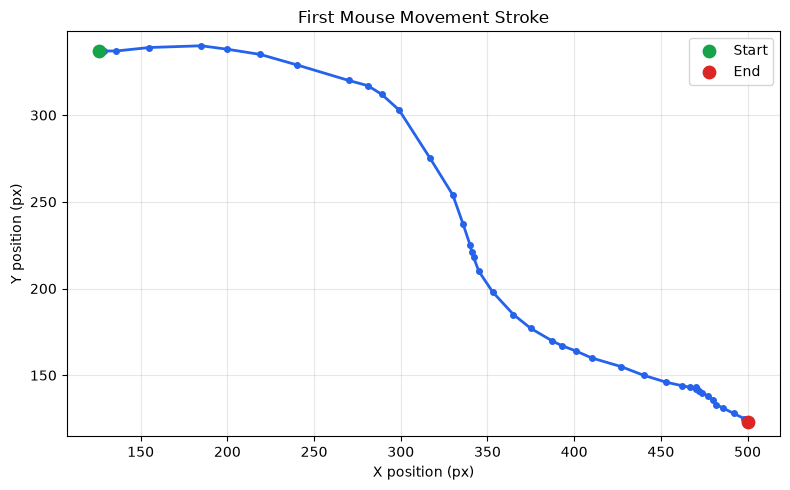

In [ ]:
import matplotlib.pyplot as plt

x_values = [point['x'] for point in points]
y_values = [point['y'] for point in points]

fig, axis = plt.subplots(figsize=(8, 5))
axis.plot(x_values, y_values, color='#2563eb', linewidth=2, marker='o', markersize=4)
axis.scatter(x_values[0], y_values[0], color='#16a34a', s=80, zorder=3, label='Start')
axis.scatter(x_values[-1], y_values[-1], color='#dc2626', s=80, zorder=3, label='End')
axis.set_title('First Mouse Movement Stroke')
axis.set_xlabel('X position (px)')
axis.set_ylabel('Y position (px)')
axis.set_aspect('equal', adjustable='datalim')
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

In [27]:
points[:1]

[{'timestamp_ms': 0.0,
  'x': 126.0,
  'y': 337.0,
  'event_type': 'Move',
  'button': 'NoButton'}]

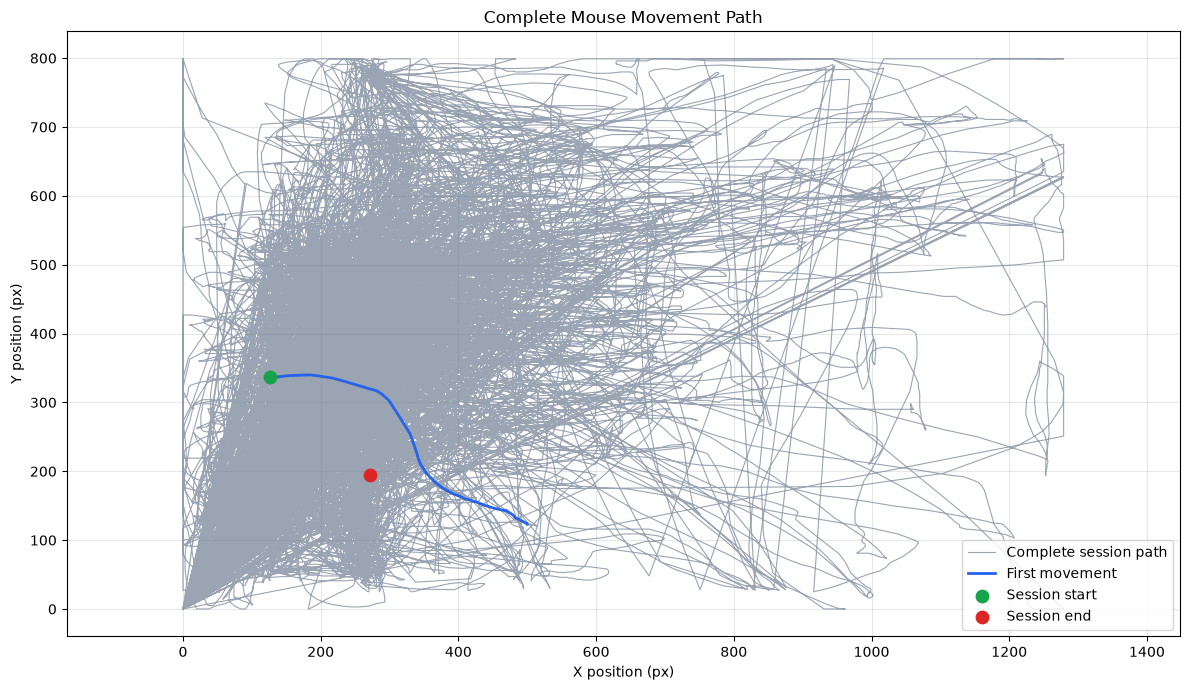

In [8]:
# Visualize the complete mouse path for the session
session_x = [event['x'] for event in events]
session_y = [event['y'] for event in events]

fig, axis = plt.subplots(figsize=(12, 7))
axis.plot(
    session_x,
    session_y,
    color='#64748b',
    linewidth=0.8,
    alpha=0.65,
    label='Complete session path',
)
axis.plot(
    x_values,
    y_values,
    color='#2563eb',
    linewidth=2,
    label='First movement',
)
axis.scatter(
    session_x[0],
    session_y[0],
    color='#16a34a',
    s=80,
    zorder=3,
    label='Session start',
)
axis.scatter(
    session_x[-1],
    session_y[-1],
    color='#dc2626',
    s=80,
    zorder=3,
    label='Session end',
)
axis.set_title('Complete Mouse Movement Path')
axis.set_xlabel('X position (px)')
axis.set_ylabel('Y position (px)')
axis.set_aspect('equal', adjustable='datalim')
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()